# ENHANCING USER AUTHENTICATION EXPERIENCE THROUGH BIG DATA ANALYSIS AND SINGLE SIGN-ON INTEGRATION
## K-MEANS ALGORITHM

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.ensemble import StackingClassifier

from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier

import numpy as np
import matplotlib.pyplot as plt

In [10]:
data = pd.read_csv('../rba-dataset/rba-dataset.csv', nrows=2000, index_col='index')

In [11]:
data.dropna(inplace=True)

In [12]:
data['Login Timestamp'] = pd.to_datetime(data['Login Timestamp'])
data['hour'] = data['Login Timestamp'].dt.hour
data['day_of_week'] = data['Login Timestamp'].dt.dayofweek
data['is_weekend'] = data['Login Timestamp'].dt.weekday >= 5
data['unique_ips'] = data.groupby('User ID')['IP Address'].transform('nunique')

# Additional features: login frequency (daily and weekly), user-based risk score
data['daily_login_count'] = data.groupby(['User ID', data['Login Timestamp'].dt.date])['Login Timestamp'].transform('count')
data['weekly_login_count'] = data.groupby(['User ID', data['Login Timestamp'].dt.to_period('W')])['Login Timestamp'].transform('count')

features = [
    'User ID', 'Round-Trip Time [ms]', 'unique_ips', 'daily_login_count', 'weekly_login_count',
    'Country', 'Region', 'City', 'ASN', 'User Agent String', 'Browser Name and Version', 
    'OS Name and Version', 'Device Type', 'Is Attack IP', 'Is Account Takeover',
    'hour', 'day_of_week', 'is_weekend'
]
target = 'Login Successful'

X = data[features]
y = data[target]

# Feature Categories
categorical_features = ['Country', 'Region', 'City', 'User Agent String',
                        'Browser Name and Version', 'OS Name and Version', 'Device Type']
numerical_features = ['User ID', 'Round-Trip Time [ms]', 'ASN', 'hour', 'day_of_week', 'is_weekend', 
                      'unique_ips', 'daily_login_count', 'weekly_login_count']

# Preprocessing pipelines for both numeric and categorical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocess and balance training data
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

smote_tomek = SMOTETomek(random_state=42)
X_train_res, y_train_res = smote_tomek.fit_resample(X_train_preprocessed, y_train)

# Define Stacking Model with additional classifiers
estimators = [
    ('rf', RandomForestClassifier(random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    ('et', ExtraTreesClassifier(random_state=42)),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
)

# Initial hyperparameter tuning with RandomizedSearchCV
param_grid = {
    'xgb__n_estimators': [50, 100, 200],
    'xgb__max_depth': [3, 6, 9],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__subsample': [0.7, 0.8, 1.0],
    'xgb__colsample_bytree': [0.7, 0.8, 1.0]
}

random_search = RandomizedSearchCV(stacking_clf, param_distributions=param_grid, n_iter=20, cv=3, scoring='roc_auc', n_jobs=-1, random_state=42)
random_search.fit(X_train_res, y_train_res)

# Fine-tuning with GridSearch on the best parameters
grid_param = {
    'xgb__n_estimators': [random_search.best_params_['xgb__n_estimators'] - 10, random_search.best_params_['xgb__n_estimators'], random_search.best_params_['xgb__n_estimators'] + 10],
    'xgb__learning_rate': [max(0.01, random_search.best_params_['xgb__learning_rate'] - 0.05), random_search.best_params_['xgb__learning_rate'], random_search.best_params_['xgb__learning_rate'] + 0.05]
}

grid_search = GridSearchCV(random_search.best_estimator_, param_grid=grid_param, scoring='roc_auc', cv=3, n_jobs=-1)
grid_search.fit(X_train_res, y_train_res)

# Initial Model Evaluation
y_pred = grid_search.predict(X_test_preprocessed)
y_pred_proba = grid_search.predict_proba(X_test_preprocessed)[:, 1]

# Capture initial evaluation metrics
initial_accuracy = accuracy_score(y_test, y_pred)
initial_report = classification_report(y_test, y_pred, output_dict=True)
initial_roc_auc = roc_auc_score(y_test, y_pred_proba)

print('Best fine-tuned parameters:', grid_search.best_params_)
print("Initial Accuracy:", initial_accuracy)
print("Initial Classification Report:", classification_report(y_test, y_pred))
print("Initial ROC-AUC Score:", initial_roc_auc)

# Adjust Decision Threshold based on ROC-AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

# Predictions with adjusted threshold
y_pred_adjusted = (y_pred_proba >= optimal_threshold).astype(int)

# Capture adjusted evaluation metrics
adjusted_accuracy = accuracy_score(y_test, y_pred_adjusted)
adjusted_report = classification_report(y_test, y_pred_adjusted, output_dict=True)
adjusted_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Adjusted Accuracy:", adjusted_accuracy)
print("Adjusted Classification Report:", classification_report(y_test, y_pred_adjusted))
print("Adjusted ROC-AUC Score:", adjusted_roc_auc)


c:\Users\HP\Documents\workspace\django app\AUTH_INSIGHT\venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:57:03] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\HP\Documents\workspace\django app\AUTH_INSIGHT\venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:57:09] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\HP\Documents\workspace\django app\AUTH_INSIGHT\venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:57:10] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_la

Best fine-tuned parameters: {'xgb__learning_rate': 0.2, 'xgb__n_estimators': 90}
Initial Accuracy: 0.7647058823529411
Initial Classification Report:               precision    recall  f1-score   support

       False       0.60      0.60      0.60         5
        True       0.83      0.83      0.83        12

    accuracy                           0.76        17
   macro avg       0.72      0.72      0.72        17
weighted avg       0.76      0.76      0.76        17

Initial ROC-AUC Score: 0.725
Adjusted Accuracy: 0.8235294117647058
Adjusted Classification Report:               precision    recall  f1-score   support

       False       0.75      0.60      0.67         5
        True       0.85      0.92      0.88        12

    accuracy                           0.82        17
   macro avg       0.80      0.76      0.77        17
weighted avg       0.82      0.82      0.82        17

Adjusted ROC-AUC Score: 0.725


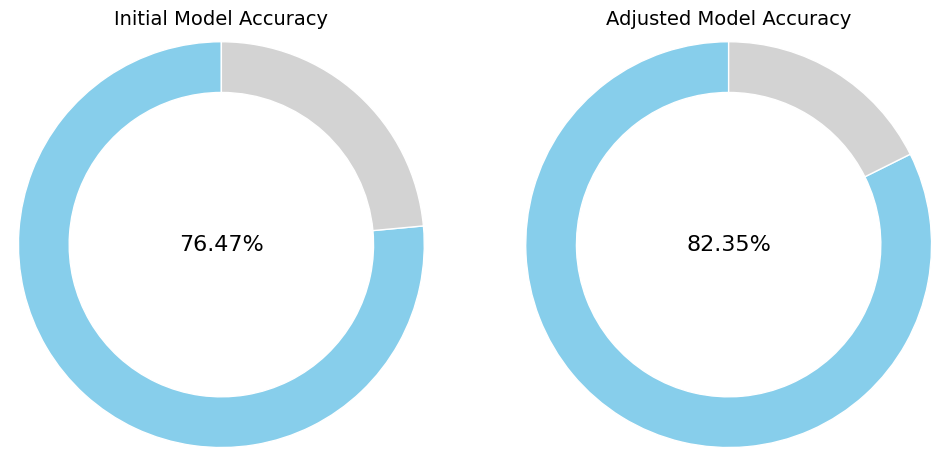

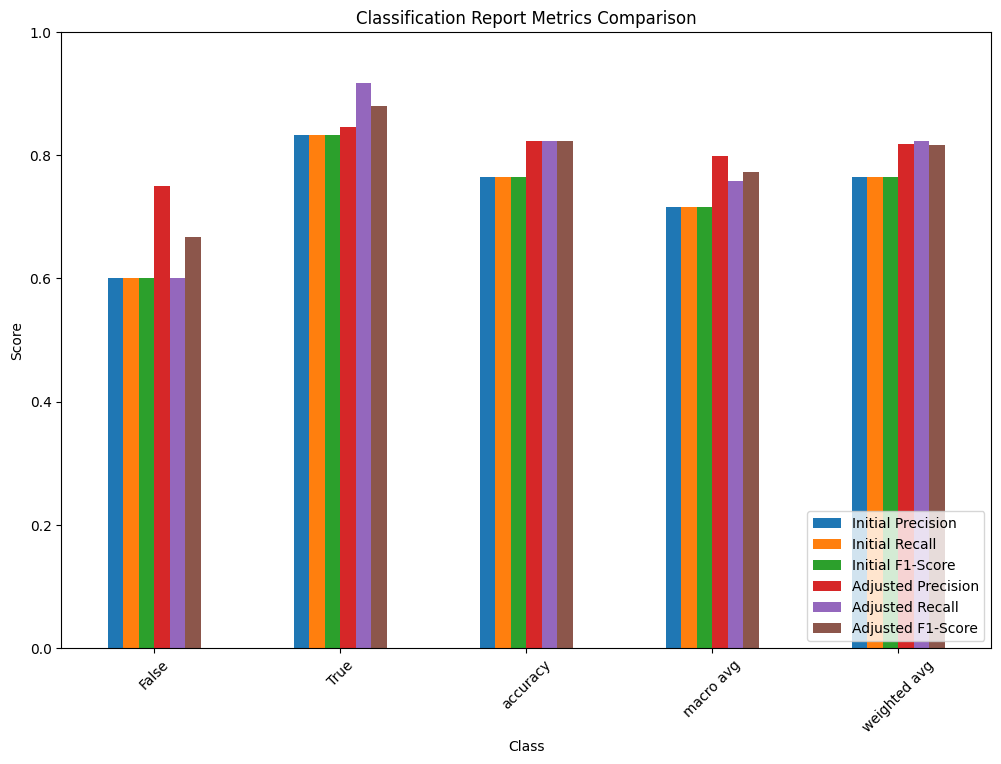

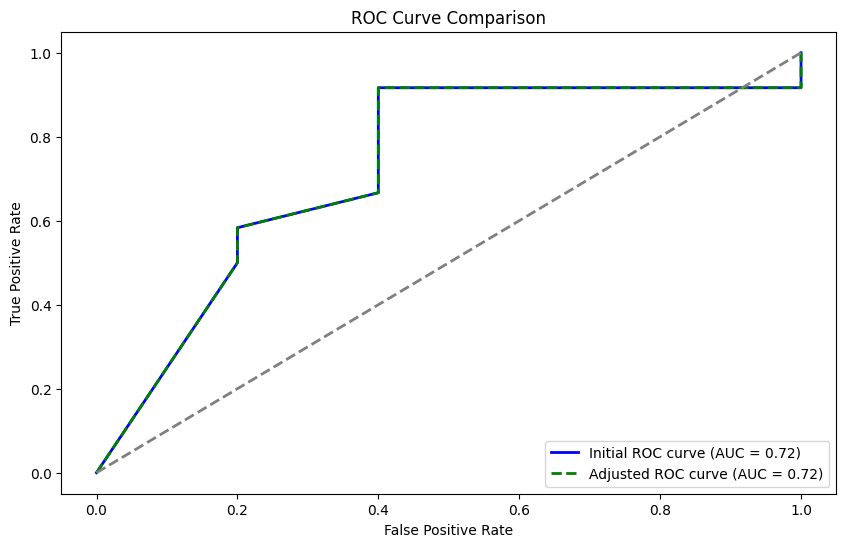

In [13]:
# Visualization
# Accuracy Donut Charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), subplot_kw=dict(aspect="equal"))

# Initial accuracy donut chart
wedges, texts = ax1.pie([initial_accuracy, 1 - initial_accuracy], 
                        radius=1.2, colors=['skyblue', 'lightgray'], startangle=90, 
                        wedgeprops=dict(width=0.3, edgecolor='w'))
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax1.add_artist(centre_circle)
ax1.set_title('Initial Model Accuracy', fontsize=14)
ax1.text(0, 0, f'{initial_accuracy:.2%}', ha='center', va='center', fontsize=16)

# Adjusted accuracy donut chart
wedges, texts = ax2.pie([adjusted_accuracy, 1 - adjusted_accuracy], 
                        radius=1.2, colors=['skyblue', 'lightgray'], startangle=90, 
                        wedgeprops=dict(width=0.3, edgecolor='w'))
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax2.add_artist(centre_circle)
ax2.set_title('Adjusted Model Accuracy', fontsize=14)
ax2.text(0, 0, f'{adjusted_accuracy:.2%}', ha='center', va='center', fontsize=16)

plt.show()

# Classification Report Metrics Comparison
# Convert initial and adjusted reports to DataFrames, keeping only precision, recall, and f1-score
initial_report_df = pd.DataFrame(initial_report).T[['precision', 'recall', 'f1-score']]
adjusted_report_df = pd.DataFrame(adjusted_report).T[['precision', 'recall', 'f1-score']]

# Rename columns for clarity
initial_report_df.columns = ['Initial Precision', 'Initial Recall', 'Initial F1-Score']
adjusted_report_df.columns = ['Adjusted Precision', 'Adjusted Recall', 'Adjusted F1-Score']

# Combine DataFrames side by side for comparison
report_comparison_df = pd.concat([initial_report_df, adjusted_report_df], axis=1)

# Plot grouped bar chart
report_comparison_df.plot(kind='bar', figsize=(12, 8))
plt.title('Classification Report Metrics Comparison')
plt.xlabel('Class')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.show()

# ROC Curve Comparison
fpr_initial, tpr_initial, _ = roc_curve(y_test, y_pred_proba)  # initial model ROC
fpr_adjusted, tpr_adjusted, _ = roc_curve(y_test, y_pred_proba)  # adjusted model ROC (using same probabilities here)

# Plot ROC curves for both initial and adjusted models
plt.figure(figsize=(10, 6))
plt.plot(fpr_initial, tpr_initial, color='blue', lw=2, linestyle='-', label=f'Initial ROC curve (AUC = {initial_roc_auc:.2f})')
plt.plot(fpr_adjusted, tpr_adjusted, color='green', lw=2, linestyle='--', label=f'Adjusted ROC curve (AUC = {adjusted_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.show()

In [14]:
import joblib

# Create a new pipeline that includes both the preprocessor and the final model
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', grid_search.best_estimator_)  # Use the fine-tuned model
])

# Fit the entire pipeline to the training data (important for retaining fit details)
final_pipeline.fit(X_train, y_train)

# Save the complete pipeline to a file
joblib_file = "final_model_pipeline.pkl"
joblib.dump(final_pipeline, joblib_file)
print(f"Model and preprocessor saved to {joblib_file}")


c:\Users\HP\Documents\workspace\django app\AUTH_INSIGHT\venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:00:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\HP\Documents\workspace\django app\AUTH_INSIGHT\venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:00:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\HP\Documents\workspace\django app\AUTH_INSIGHT\venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:00:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_la

Model and preprocessor saved to final_model_pipeline.pkl
